# Selección de Método Anticonceptivo
### Clasificación: AdaBoosting

Los de este ejemplo provienen  de la Encuesta Nacional de Indonesia sobre Prevalencia de Anticonceptivos de 1987. En la muestra se recopilan los datos de mujeres que están casadas y 
que no estaban embarazadas o no sabían si estaban embarazadas en el momento de la entrevista. 
El problema es predecir el método anticonceptivo empleado por la esposa (sin uso, métodos a largo plazo o métodos a corto plazo) en función de sus características demográficas y socioeconómicas. Hay tres clases de respuestas en la variable objetivo, dos atributos numéricos, siete atributos categóricos y 1473 registros. Las tasas de error se estiman mediante una validación cruzada de 10 conjuntos.

### Descripción de los atributos

1. Edad de la mujer                    (numerical)
2. Nivel educativo mujer               (categorical)      1=low, 2, 3, 4=high
3. Nivel educativo hombre              (categorical)      1=low, 2, 3, 4=high
4. Número de hijos                     (numerical)
5. Religión de la mujer                (binary)           0=Non-Islam, 1=Islam
6. Mujer trabajo                       (binary)           0=Yes, 1=No
7. Ocupación del hombre                (categorical)      1, 2, 3, 4
8. Indice de nivel de vida             (categorical)      1=low, 2, 3, 4=high
9. Exposición a medios                 (binary)           0=Good, 1=Not good
10. Método contraceptivo empleado      (class attribute)  1=No-use, 2=Long-term, 3=Short-term

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
datos=pd.read_csv("cmc.csv")
datos.head()

,Edad,NE_mujer,NE_hombre,N_hijos,Religion,Mujer_trabaja,Ocupacion,Nivel_vida,Exposicion_medios,Tipo_anticonceptivo
0,24,2,3,3,1,1,2,3,0,1
1,45,1,3,10,1,1,3,4,0,1
2,43,2,3,7,1,1,3,4,0,1
3,42,3,2,9,1,1,3,3,0,1
4,36,3,3,8,1,1,3,2,0,1


In [3]:
datos.describe()

,Edad,NE_mujer,NE_hombre,N_hijos,Religion,Mujer_trabaja,Ocupacion,Nivel_vida,Exposicion_medios,Tipo_anticonceptivo
count,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000
mean,32.538357,2.958588,3.429735,3.261371,0.850645,0.749491,2.137814,3.133741,0.073999,1.919891
std,8.227245,1.014994,0.816349,2.358549,0.356559,0.433453,0.864857,0.976161,0.261858,0.876376
min,16.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,26.000000,2.000000,3.000000,1.000000,1.000000,0.000000,1.000000,3.000000,0.000000,1.000000
50%,32.000000,3.000000,4.000000,3.000000,1.000000,1.000000,2.000000,3.000000,0.000000,2.000000
75%,39.000000,4.000000,4.000000,4.000000,1.000000,1.000000,3.000000,4.000000,0.000000,3.000000
max,49.000000,4.000000,4.000000,16.000000,1.000000,1.000000,4.000000,4.000000,1.000000,3.000000


**El error estándar y los intervalos de confianza**. 
Sea x_1,x_2,...,x_n una muestra de una población con media Mu y varianza sigma2. El Teorema del Límite Central, nos dice que el promedio de x_1,x_2,...,x_n tiene una distribución de probabilidad normal con media Mu y varianza sigma2/n, donde n es el tamaño de la muestra. 

_Error estándar:_ sqrt(sigma2/n) se emplea para calcular un intervalo del 95% de confianza para la media poblacional Mu a partir de la fómula:

                            promedio(x_1,x_2,....x_n) +/- 2*Error Estándar.  


# Analisis Exploratorio de Datos

El tamaño de la muesta es de n=1473, mujeres casadas, y que están o no saben si están embarazadas en el momento de la entrevista. La edad promedio que observada es 32.53 años con una desviación estándar de 8.22 años. De este modo un intervalo de confianza del 95% para la edad promedio de las mujeres casada es (32.10, 32.96).    

In [4]:
n=1473
datos.Edad.mean()-2*datos.Edad.std()/np.sqrt(n),datos.Edad.mean()+2*datos.Edad.std()/np.sqrt(n)

(32.109627917884836, 32.96708627084564)

<Axes: xlabel='Edad', ylabel='Count'>

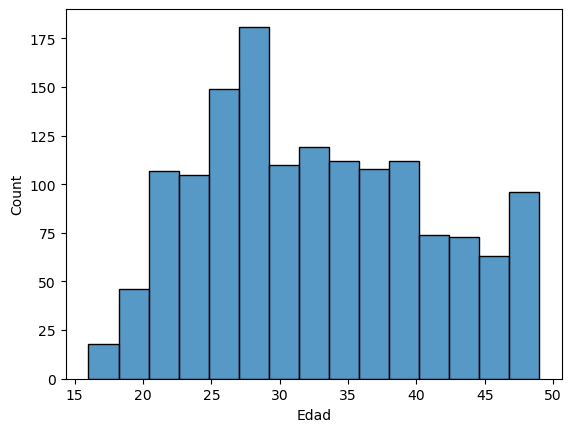

In [5]:
sns.histplot(x=datos.Edad)

<Axes: ylabel='Count'>

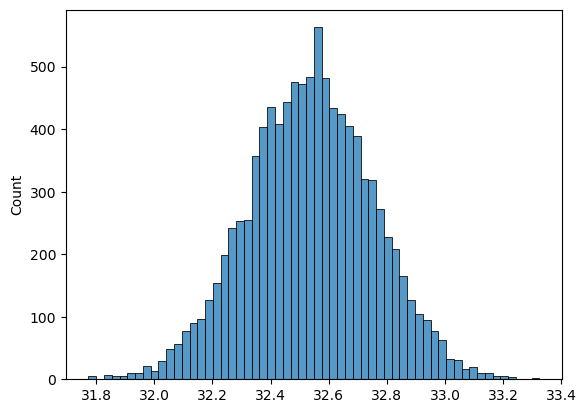

In [6]:
# Muestreo bootstrap
muestra=datos.Edad
M=10000
edad_promedio=[]
for i in np.arange(0,M):
    muestra_b=np.random.choice(muestra, len(muestra), replace=True)
    edad_promedio.append(muestra_b.mean())
sns.histplot(x=edad_promedio)
    

In [7]:
np.quantile(edad_promedio,q=[0.025,0.975])  # Este es un intervalo del 95%

# Es similiar al obtenido previamente.. 

array([32.1065852 , 32.95994569])

<Axes: xlabel='Tipo_anticonceptivo', ylabel='Edad'>

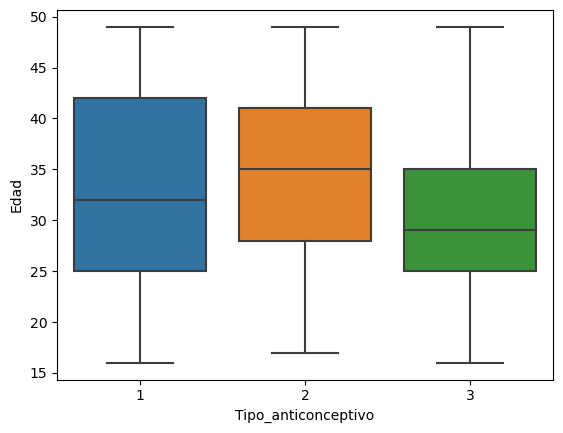

In [8]:
sns.boxplot(x=datos.Tipo_anticonceptivo,y=datos.Edad)

<Axes: xlabel='NE_mujer', ylabel='N_hijos'>

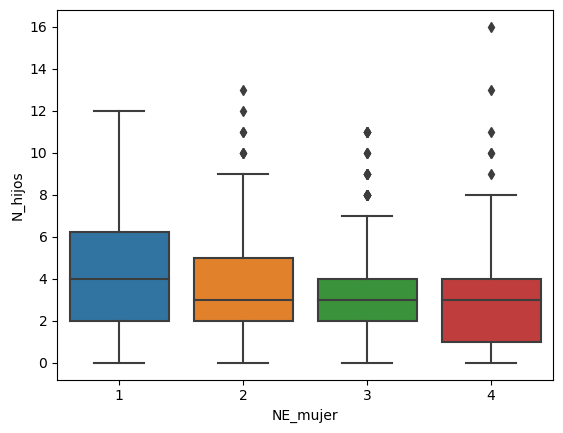

In [9]:
sns.boxplot(x=datos.NE_mujer,y=datos.N_hijos)

<Axes: xlabel='Nivel_vida', ylabel='N_hijos'>

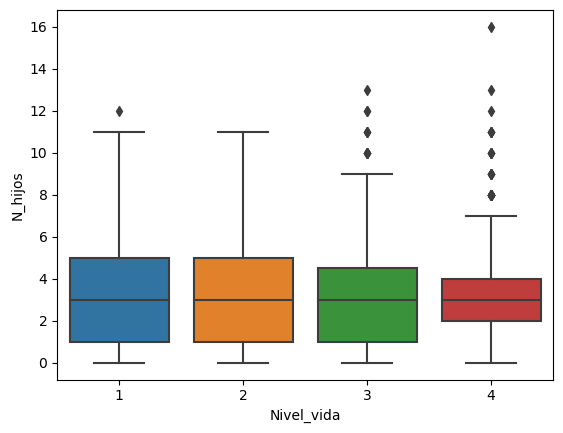

In [10]:
sns.boxplot(x=datos.Nivel_vida,y=datos.N_hijos)

<Axes: xlabel='Tipo_anticonceptivo', ylabel='Edad'>

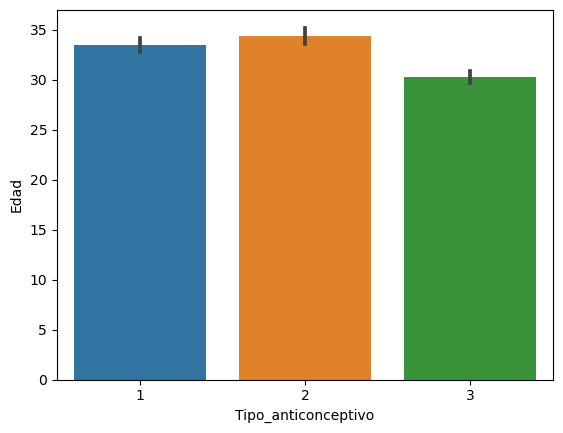

In [11]:
sns.barplot(x=datos.Tipo_anticonceptivo,y=datos.Edad)

El promedio de hijos por mujer es de 3.26 con una desviación estándar de 2.36. Un intervalo del 95% de cofianza para el promedio de hijos por mujer es (3.19, 3.32). 
NOTA: La hipótesis del promedio de hijos por mujer igual a 3, se rechaza. 

In [12]:
datos.N_hijos.mean(), datos.N_hijos.std()   

(3.2613713509843856, 2.358548862687412)

In [13]:
3.26 - 2.36/np.sqrt(n), 3.26 + 2.36/np.sqrt(n) 

(3.1985091311510474, 3.321490868848952)

<Axes: xlabel='Tipo_anticonceptivo', ylabel='N_hijos'>

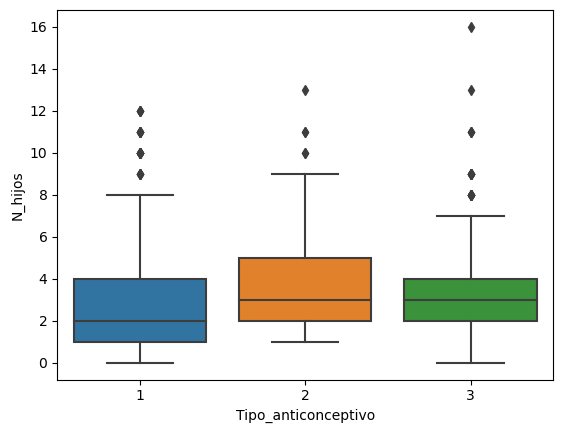

In [14]:
sns.boxplot(x=datos.Tipo_anticonceptivo,y=datos.N_hijos)

<Axes: xlabel='Tipo_anticonceptivo', ylabel='N_hijos'>

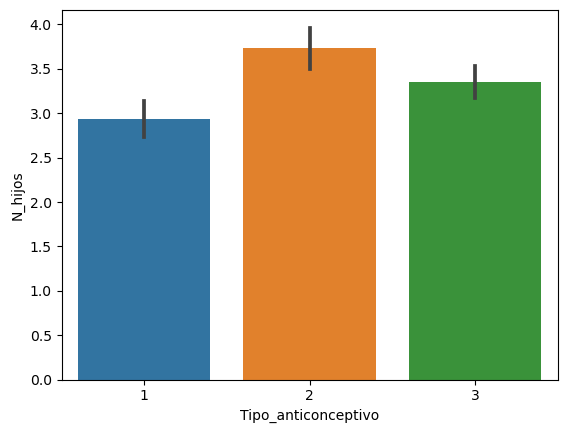

In [15]:
sns.barplot(x=datos.Tipo_anticonceptivo,y=datos.N_hijos)

<Axes: xlabel='Edad', ylabel='N_hijos'>

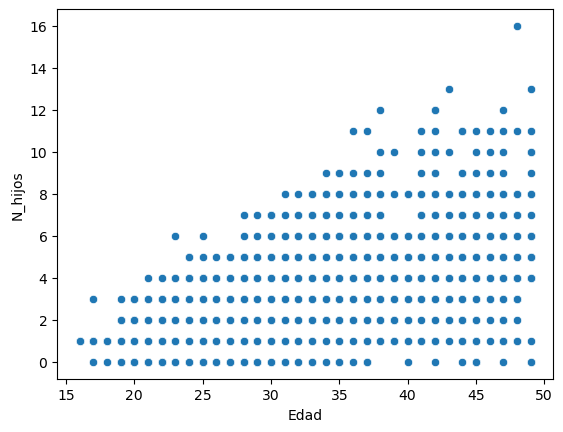

In [16]:
sns.scatterplot(x=datos.Edad,y=datos.N_hijos)

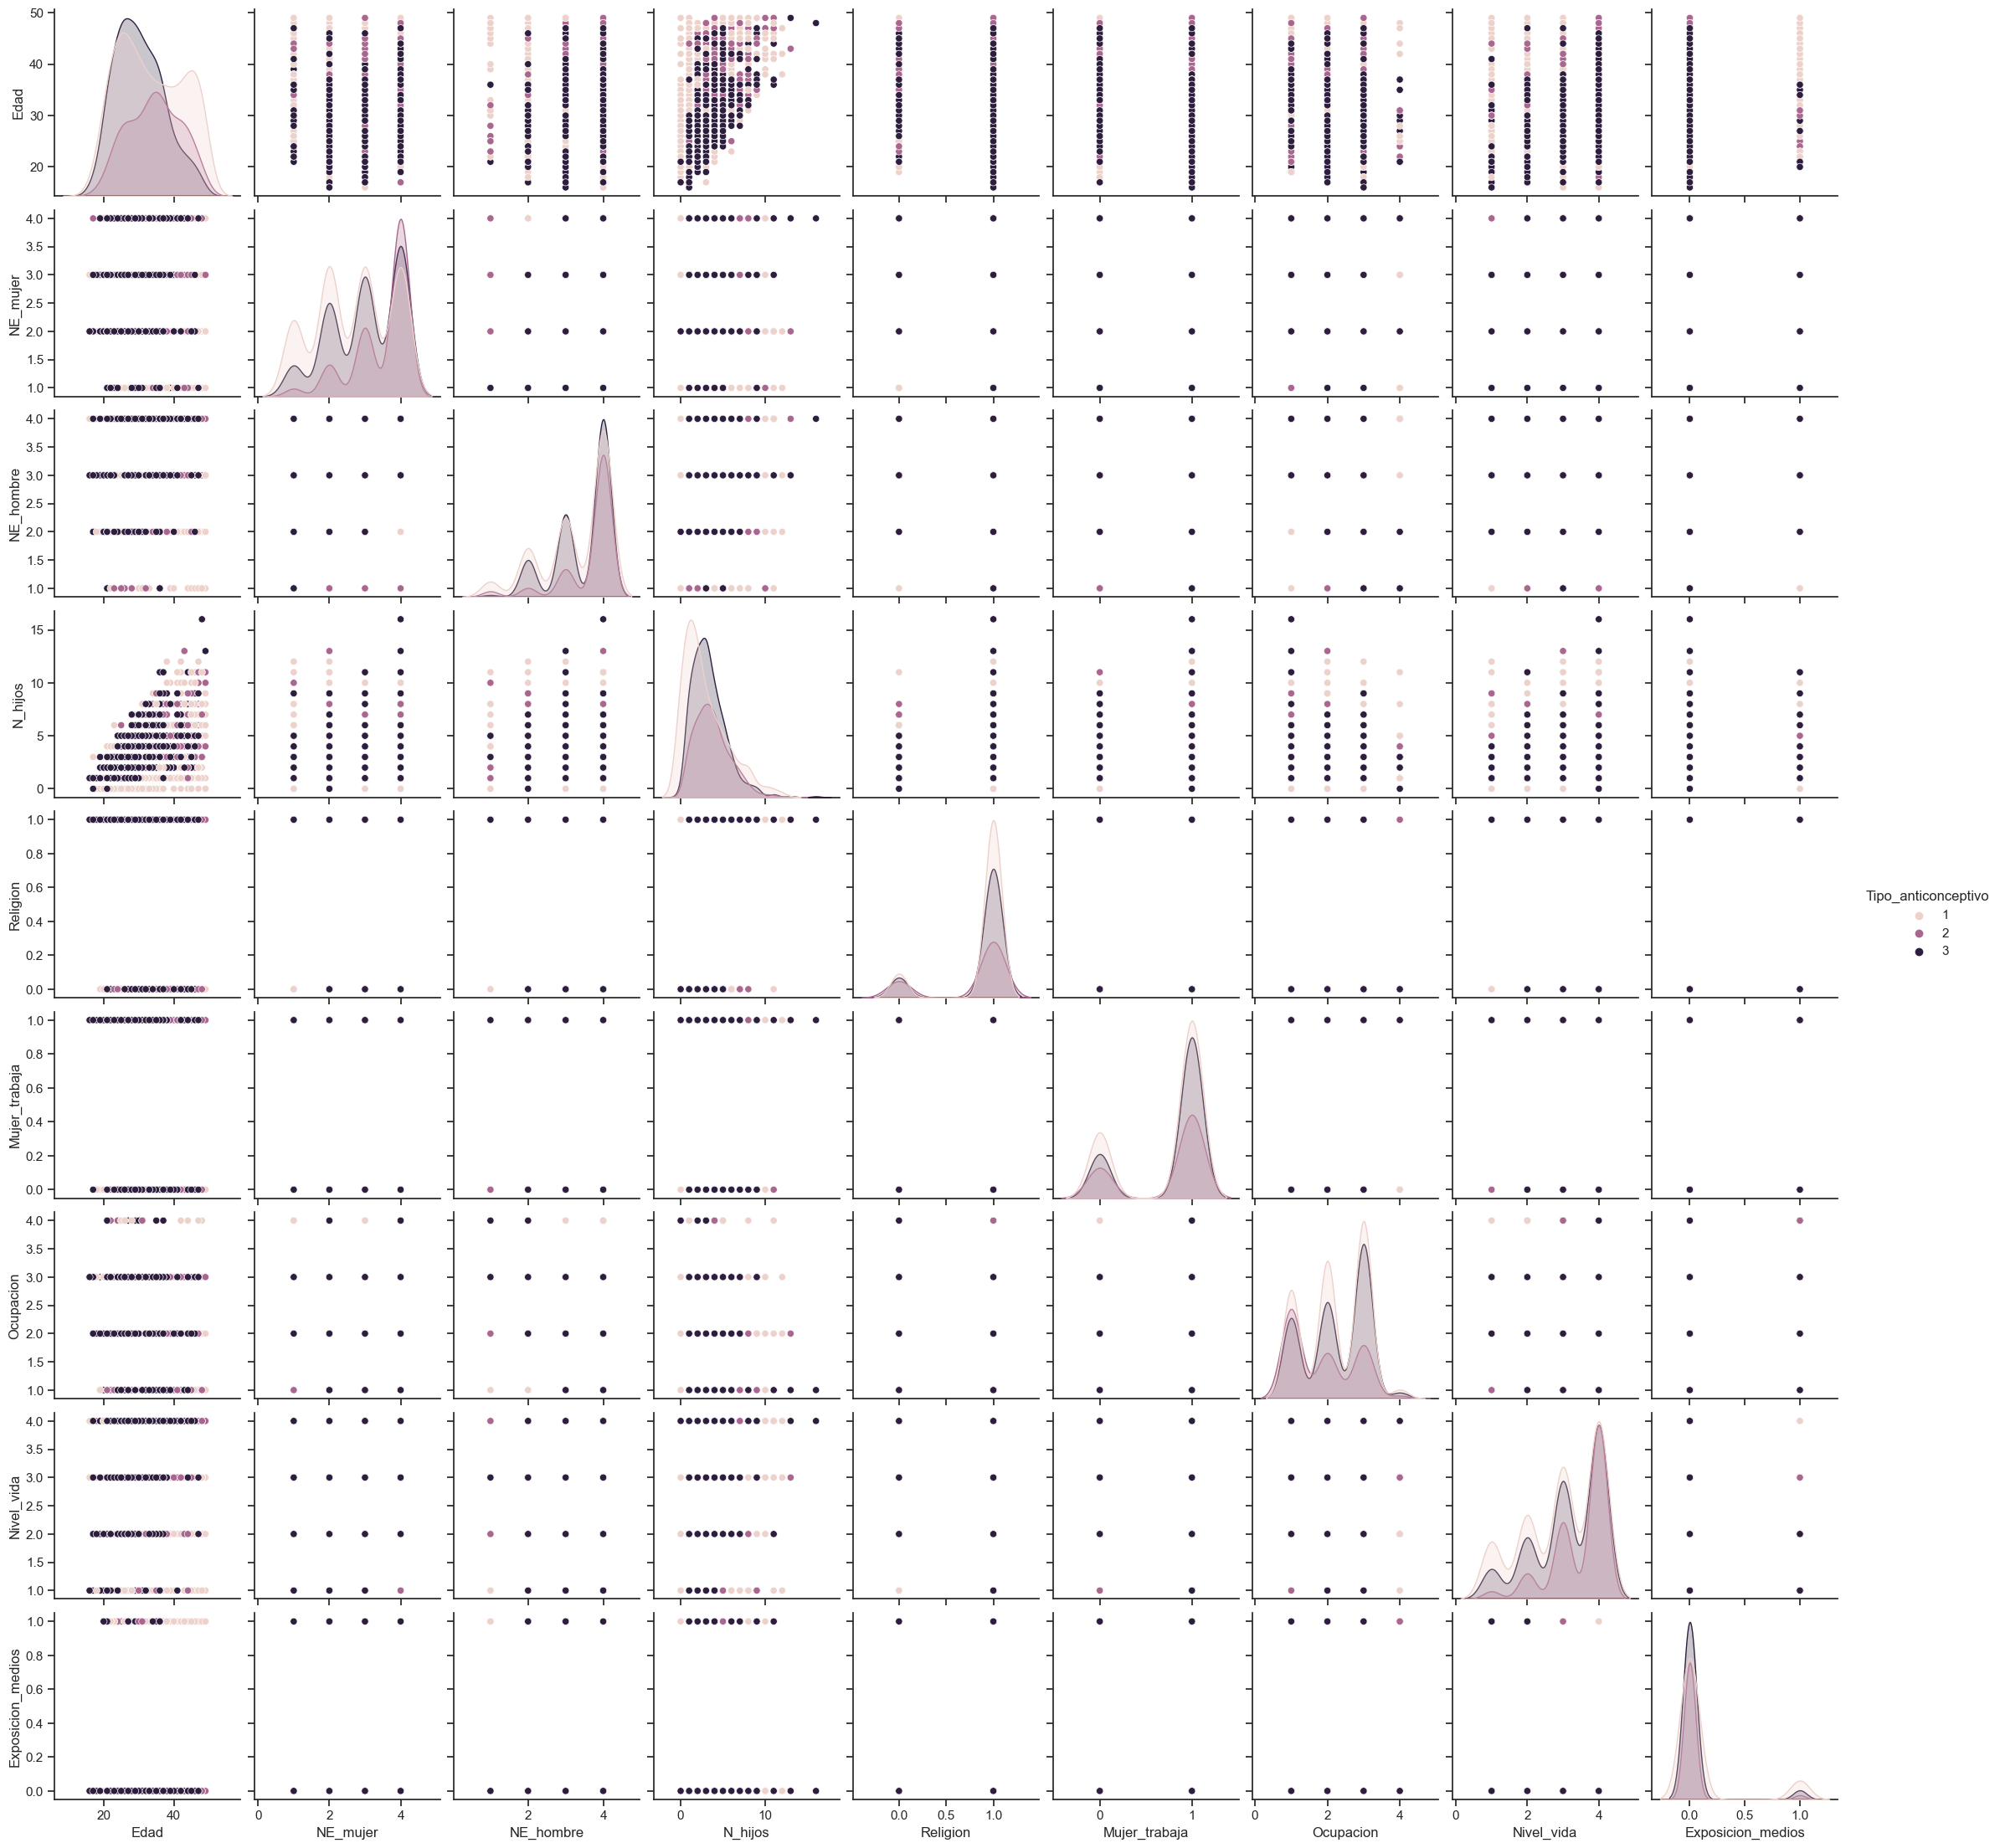

In [17]:
sns.set_theme(style="ticks")
sns.pairplot(datos,hue="Tipo_anticonceptivo")

In [18]:
# Clasificación AdaBoosting
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

In [19]:
# Seleccionamos los atributos y el target
y=datos["Tipo_anticonceptivo"]
del datos["Tipo_anticonceptivo"]
X=datos

In [20]:
X.columns

Index(['Edad', 'NE_mujer', 'NE_hombre', 'N_hijos', 'Religion', 'Mujer_trabaja',
       'Ocupacion', 'Nivel_vida', 'Exposicion_medios'],
      dtype='object')

In [21]:
# Crear las dummies para las categóricas. 
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

colum_transf=make_column_transformer((OneHotEncoder(), ['NE_mujer', 'NE_hombre','Religion',
                                                        'Mujer_trabaja','Ocupacion', 'Nivel_vida',
                                                        'Exposicion_medios']),remainder="passthrough")



In [22]:
X_dummies=colum_transf.fit_transform(X)
X_dummies

array([[ 0.,  1.,  0., ...,  0., 24.,  3.],
       [ 1.,  0.,  0., ...,  0., 45., 10.],
       [ 0.,  1.,  0., ...,  0., 43.,  7.],
       ...,
       [ 0.,  0.,  1., ...,  0., 39.,  8.],
       [ 0.,  0.,  1., ...,  0., 33.,  4.],
       [ 0.,  0.,  1., ...,  0., 17.,  1.]])

In [23]:
modelo=AdaBoostClassifier()
scores=cross_val_score(modelo,X_dummies,y,scoring="accuracy",cv=10,n_jobs=-1)
print("La exactitud promedio es {:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La exactitud promedio es 0.545 +/- 0.032


In [24]:
# Si nos preguntamos por la tarea de clasificación: emplea un método anticonceptivo o
# no emplea método anticonceptivo.
y_recod=y.replace({1:0,2:1,3:1})


In [25]:
y_recod.value_counts(normalize=True)

1    0.57298
0    0.42702
Name: Tipo_anticonceptivo, dtype: float64

In [26]:
modelo=AdaBoostClassifier()
scores=cross_val_score(modelo,X_dummies,y_recod,scoring="accuracy",cv=10,n_jobs=-1)
print("La exactitud promedio es {:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La exactitud promedio es 0.720 +/- 0.036


# Trabajamos con el Imbalance de los datos



In [27]:
# Sobre muestreo

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import make_pipeline

In [28]:
pipe=make_pipeline(RandomOverSampler(),AdaBoostClassifier(n_estimators=30))
scores=cross_val_score(pipe,X_dummies,y_recod,scoring="accuracy",cv=10,n_jobs=-1)
print("La exactitud promedio es {:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La exactitud promedio es 0.707 +/- 0.033


In [29]:
from imblearn.under_sampling import NearMiss
pipe=make_pipeline(NearMiss(n_neighbors=6),AdaBoostClassifier(n_estimators=30))
scores=cross_val_score(pipe,X_dummies,y_recod,scoring="accuracy",cv=10,n_jobs=-1)
print("La exactitud promedio es {:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La exactitud promedio es 0.693 +/- 0.038


In [30]:
from imblearn.combine import SMOTETomek
pipe=make_pipeline(SMOTETomek(),AdaBoostClassifier(n_estimators=30))
scores=cross_val_score(pipe,X_dummies,y_recod,scoring="accuracy",cv=10,n_jobs=-1)
print("La exactitud promedio es {:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La exactitud promedio es 0.713 +/- 0.043


In [31]:
# Modelo Final...
# 1. Trabajamos con Smote-Tomek
# 2. Ajustar un modelo con AdaBoost

# Comenzamos entrenando el modelo empleando Todos los datos. Primero aplicamos la
# técnica de Smote-Tomek a los datos ya con las dummies.

remuestreo=SMOTETomek()
X_resample,y_resample=remuestreo.fit_resample(X_dummies,y_recod)

modelo=AdaBoostClassifier()
modelo.fit(X_resample,y_resample)   # Este modelo ya me sirve para hacer predicciones

AdaBoostClassifier()

In [32]:
# Cómo hacemos las predicciones
datos_nuevos=pd.DataFrame({'Edad':[28], 'NE_mujer':[3], 'NE_hombre':[3], 'N_hijos':[1],
                           'Religion':[1], 'Mujer_trabaja':[1],'Ocupacion':[2], 'Nivel_vida':[2],
                           'Exposicion_medios':[0]})
datos_nuevos

,Edad,NE_mujer,NE_hombre,N_hijos,Religion,Mujer_trabaja,Ocupacion,Nivel_vida,Exposicion_medios
0,28,3,3,1,1,1,2,2,0


In [33]:
# Transformamos los datos
datos_nuevos_trans=colum_transf.transform(datos_nuevos)
datos_nuevos_trans

array([[ 0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  1.,  0.,  1.,  0.,
         1.,  0.,  0.,  0.,  1.,  0.,  0.,  1.,  0., 28.,  1.]])

In [34]:
modelo.predict(datos_nuevos_trans)

array([0], dtype=int64)

# Resolver el mismo problema con GradientBoosting

In [37]:
from sklearn.ensemble import GradientBoostingClassifier


In [41]:
modelo=GradientBoostingClassifier(learning_rate=0.01,max_leaf_nodes=8)
scores=cross_val_score(modelo,X_dummies,y_recod,scoring="accuracy",cv=10,n_jobs=-1)
print("La exactitud promedio es {:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La exactitud promedio es 0.718 +/- 0.031


In [ ]:
# Con Gradient Boosting logramos una exactitud de 71.8%

In [45]:
from sklearn.model_selection import GridSearchCV

# Calibración.
espacio_parametral={"learning_rate":[0.01,0.05,0.1,0.12],
                   "max_leaf_nodes":[2,3,4,5,6,8,12,14]}

modelo=GradientBoostingClassifier()
modelo_candidatos=GridSearchCV(modelo,param_grid=espacio_parametral,scoring="accuracy",
                              cv=10,n_jobs=-1)
modelo_candidatos.fit(X_dummies,y_recod)

print("La mejor configuración es ", modelo_candidatos.best_params_)
print("La mejor métrica ", modelo_candidatos.best_score_)

La mejor configuración es  {'learning_rate': 0.12, 'max_leaf_nodes': 3}
La mejor métrica  0.7297710976282404


In [ ]:
# Con GradientBoosting,  {'learning_rate': 0.12, 'max_leaf_nodes': 3} 
# logramos una exactitud del 72.9%.

In [46]:
# Validación cruzada anidada.

# Calibración.
espacio_parametral={"learning_rate":[0.01,0.05,0.1,0.12],
                   "max_leaf_nodes":[2,3,4,5,6,8,12,14]}
modelo=GradientBoostingClassifier()
# En la siguiente linea se resuelve el problema de la selección de modelo.
modelo_candidatos=GridSearchCV(modelo,param_grid=espacio_parametral,scoring="accuracy",
                              cv=10,n_jobs=-1)
# Calificamos el desempeño del modelo seleccionado en datos "nuevos"
scores=cross_val_score(modelo_candidatos,X_dummies,y_recod, scoring="accuracy",
                      cv=10,n_jobs=-1)
print("La exactitud promedio es {:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))


La exactitud promedio es 0.724 +/- 0.032


La exactitud anterior es la exactitud promedio del modelo en datos que no vio en fases de 
entrenamiento y/o en la fase de seleccionar el mejor modelo. 
Vemos que no hay mucha diferencia en las exactitudes en la validación cruzada y la validación 
cruzada anidada. Podemos entonces estar seguros de que no hay un sobreajuste del modelo.

# Incluir un método de balanceo de los datos.

In [47]:
from imblearn.combine import SMOTETomek

# Calibración.
espacio_parametral={"gradientboostingclassifier__learning_rate":[0.01,0.05,0.1,0.12],
                   "gradientboostingclassifier__max_leaf_nodes":[2,3,4,5,6,8,12,14]}

modelo=make_pipeline(SMOTETomek(),GradientBoostingClassifier()) 
modelo_candidatos=GridSearchCV(modelo,param_grid=espacio_parametral,scoring="accuracy",
                              cv=10,n_jobs=-1)
modelo_candidatos.fit(X_dummies,y_recod)

print("La mejor configuración es ", modelo_candidatos.best_params_)
print("La mejor métrica ", modelo_candidatos.best_score_)


La mejor configuración es  {'gradientboostingclassifier__learning_rate': 0.12, 'gradientboostingclassifier__max_leaf_nodes': 4}
La mejor métrica  0.7270546056260342


In [48]:
# Validación cruzada anidada.

# Calibración.
# Calibración.
espacio_parametral={"gradientboostingclassifier__learning_rate":[0.01,0.05,0.1,0.12],
                   "gradientboostingclassifier__max_leaf_nodes":[2,3,4,5,6,8,12,14]}

modelo=make_pipeline(SMOTETomek(),GradientBoostingClassifier()) 
# En la siguiente linea se resuelve el problema de la selección de modelo.
modelo_candidatos=GridSearchCV(modelo,param_grid=espacio_parametral,scoring="accuracy",
                              cv=10,n_jobs=-1)
# Calificamos el desempeño del modelo seleccionado en datos "nuevos"
scores=cross_val_score(modelo_candidatos,X_dummies,y_recod, scoring="accuracy",
                      cv=10,n_jobs=-1)
print("La exactitud promedio es {:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))


La exactitud promedio es 0.715 +/- 0.034


In [ ]:
# Tenemos la seguridad de que el modelo no está sobreajustado